Функция для очистки от выбросов группы watch_time

In [1]:
def clean_watch_time(group):
    q1, q3 = group["watch_time"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - iqr*1.5, q3 + iqr*1.5

    outlier_idx = group.index[(group["watch_time"] < lower) | (group["watch_time"] > upper)]
        
    for idx in outlier_idx:
        val = group.loc[idx, "watch_time"]
        fixed = None
        if lower < val < upper:
            fixed = val
        group.loc[idx, "watch_time"] = fixed
        
    return group

Очистка и просмотр данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

data = pd.read_json("data\\ab_test.jsonl", lines=True)
data["subscription"] = (data["subscription"]
                      .str.lower()
                      .str.strip()
                      .str.replace("prem", "premium", regex=True)
                      .str.replace("premiumium", "premium", regex=True)
                      .str.replace("standard", "standart", regex=True))
data.drop_duplicates(inplace=True)
data = (data[(data["watch_time"] >= 0)
         & (data["movies_started"] >= data["movies_finished"])
         & ((data["age"] > 0) & (data["age"] < 100))])

data = clean_watch_time(data)
data.dropna(inplace=True)


    # Просмотр данных
print(data.sort_values("group", ignore_index=True).head(20))
print()

print(data.groupby("group")["age"].describe())
print()
print(data.groupby('group')["watch_time"].describe())

    user_id group  age gender country    device subscription  watch_time  \
0         1     A   42      M      IT  smart_tv         free       133.2   
1         2     A   56      F      SE    mobile     standart       258.6   
2         8     A   24      M      ES  smart_tv     standart       660.4   
3        14     A   24      F      CZ    tablet         free       358.3   
4        15     A   34      M      CZ  smart_tv         free        90.7   
5        18     A   22      M      FI    tablet      premium       452.6   
6        19     A   51      M      FI    tablet     standart       297.3   
7        20     A   23      F      DE    mobile      premium       537.8   
8        26     A   40      M      US    tablet      premium       274.0   
9        28     A   27      M      PL   desktop      premium       463.5   
10       31     A   60      F      IT    mobile         free       392.0   
11       39     A   56      F      IT  smart_tv         free       568.9   
12       40 

Диаграммы основных параметров групп A и B

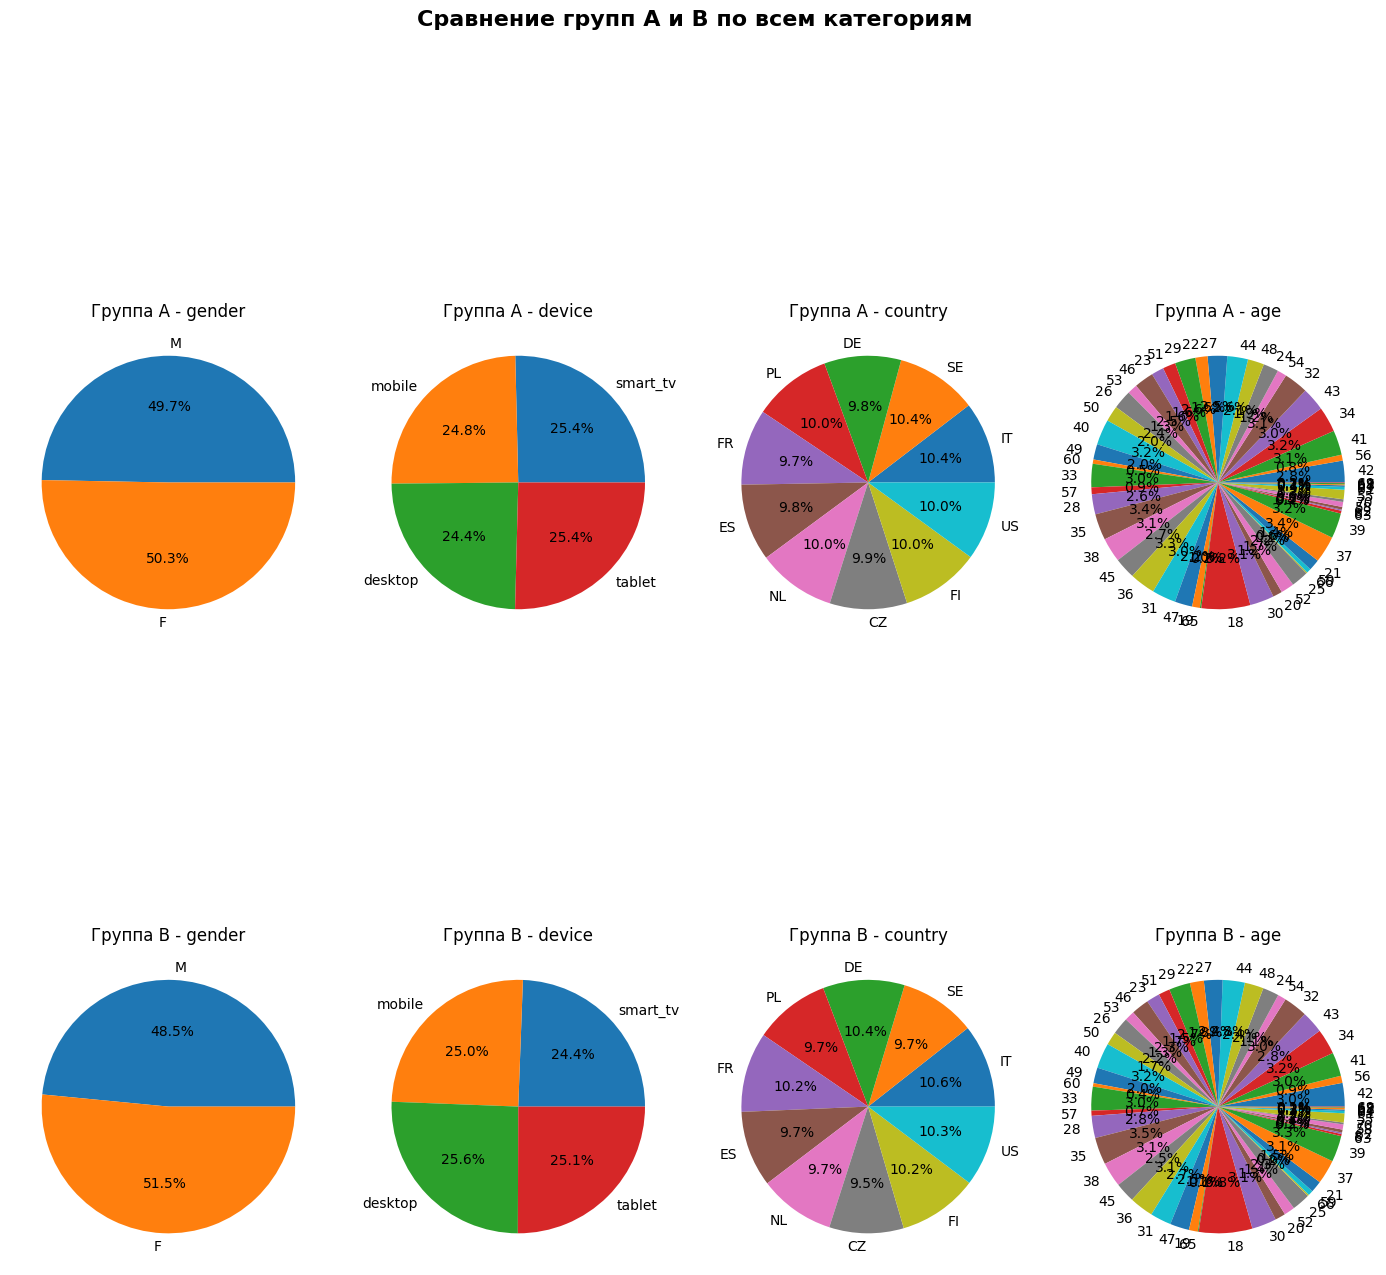

In [3]:
genders = data["gender"].unique()
devices = data["device"].unique()
countries = data["country"].unique()
ages = data["age"].unique()

fig, axes = plt.subplots(2, 4, figsize=(14, 16))
fig.suptitle("Сравнение групп A и B по всем категориям", fontsize=16, fontweight='bold')

uniques = [genders, devices, countries, ages]
categories = ["gender", "device", "country", "age"]
for i in range(4):
    counts_A_gender = data[data["group"] == "A"].groupby(categories[i])["group"].count()
    counts_B_gender = data[data["group"] == "B"].groupby(categories[i])["group"].count()
    counts_A_gender = counts_A_gender.reindex(uniques[i], fill_value=0)
    counts_B_gender = counts_B_gender.reindex(uniques[i], fill_value=0)
    axes[0, i].pie(counts_A_gender, labels=uniques[i], autopct='%1.1f%%')
    axes[0, i].set_title(f"Группа A - {categories[i]}")
    axes[1, i].pie(counts_B_gender, labels=uniques[i], autopct='%1.1f%%')
    axes[1, i].set_title(f"Группа B - {categories[i]}")

for ax in axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()

Проверка корректности данных через хи-квадрат

In [5]:
A_group = data[data["group"] == "A"]
B_group = data[data["group"] == "B"]

    # Гаджеты
table_devices = pd.crosstab(data["group"], data["device"])
chi, p, dof, expected = stats.chi2_contingency(table_devices)
print(f"Значения для гаджетов:\nХи-квадрат: {chi}\nP-value: {p}\nКол-во степеней свободы: {dof}\n")
    # Страна
table_countries = pd.crosstab(data["group"], data["country"])
chi2, p2, dof2, expected2 = stats.chi2_contingency(table_countries)
print(f"Значения для стран:\nХи-квадрат: {chi2}\nP-value: {p2}\nКол-во степеней свободы: {dof2}\n")
    # Возраст
table_ages = pd.crosstab(data["group"], data["age"])
chi3, p3, dof3, expected3 = stats.chi2_contingency(table_ages)
print(f"Значения для возраста:\nХи-квадрат: {chi3}\nP-value: {p3}\nКол-во степеней свободы: {dof3}\n")
    # Пол
table_gender = pd.crosstab(data["group"], data["gender"])
chi4, p4, dof4, expected4 = stats.chi2_contingency(table_gender)
print(f"Значения для пола:\nХи-квадрат: {chi4}\nP-value: {p4}\nКол-во степеней свободы: {dof4}\n")

Значения для гаджетов:
Хи-квадрат: 4.065274051866853
P-value: 0.2545014291874784
Кол-во степеней свободы: 3

Значения для стран:
Хи-квадрат: 7.029832901098525
P-value: 0.6340132450658298
Кол-во степеней свободы: 9

Значения для возраста:
Хи-квадрат: 41.90956653773018
P-value: 0.8636967755434948
Кол-во степеней свободы: 53

Значения для пола:
Хи-квадрат: 2.5907585327931604
P-value: 0.10748884736149557
Кол-во степеней свободы: 1



Результат говорит о независимости принадлежности к какой-либо группе и других основных метрик. В совокупности с диаграммами, можно точно сказать, что данные между группами распределены корректно

Проверка по t-критерию Стьюдента разных метрик

In [8]:
    # Проверка увеличения среднего времени просмотра
len_A = len(data[data["group"] == "A"])
len_B = len(data[data["group"] == "B"])
df = len_A + len_B - 2
alpha = 0.05

standart_error_wt = (((data[data["group"] == "A"]["watch_time"].std()**2)/len_A) + ((data[data["group"] == "B"]["watch_time"].std()**2)/len_B)) ** 0.5
t_observed_wt = abs(data[data["group"] == "A"]["watch_time"].mean() - data[data["group"] == "B"]["watch_time"].mean())/standart_error_wt
t_critical = stats.t.ppf(1 - alpha, df)

print()
print("t-значения времени просмотра:")
print(t_critical)
print(t_observed_wt)
print()

    # Проверка кол-ва завершённы фильмов
standart_error_mf = (((data[data["group"] == "A"]["movies_finished"].std()**2)/len_A) + ((data[data["group"] == "B"]["movies_finished"].std()**2)/len_B)) ** 0.5
t_observed_mf = abs(data[data["group"] == "A"]["movies_finished"].mean() - data[data["group"] == "B"]["movies_finished"].mean())/standart_error_mf

print("t-значения кол-ва завершённых фильмов:")
print(t_critical)
print(t_observed_mf)
print()

    # Проверка вероятности подписки
p_subscription_A = data[data["group"] == "A"]["subscription_bought"].mean()
q_subscription_A = 1 - p_subscription_A

p_subscription_B = data[data["group"] == "B"]["subscription_bought"].mean()
q_subscription_B = 1 - p_subscription_B

mean_subscription_A = p_subscription_A
mean_subscription_B = p_subscription_B

std_subscription_A = (p_subscription_A*q_subscription_A) ** 0.5
std_subscription_B = (p_subscription_B*q_subscription_B) ** 0.5

standart_error_sub = (((std_subscription_A**2)/len_A) + ((std_subscription_B**2)/len_B)) ** 0.5
t_observed_sub = abs(mean_subscription_A - mean_subscription_B)/standart_error_sub

print("t-значнения вероятности подписки:")
print(t_critical)
print(t_observed_sub)
print()

    # Проверка работы рекомендаций
p_rec_A = data[data["group"] == "A"]["clicked_recommendation"].mean()
q_rec_A = 1 - p_rec_A

p_rec_B = data[data["group"] == "B"]["clicked_recommendation"].mean()
q_rec_B = 1 - p_rec_B

mean_rec_A = p_rec_A
mean_rec_B = p_rec_B

std_rec_A = (p_rec_A*q_rec_A)**0.5
std_rec_B = (p_rec_B*q_rec_B)**0.5

standart_error_rec = (((std_rec_A**2)/len_A) + ((std_rec_B**2)/len_B)) ** 0.5
t_observed_rec = abs(mean_rec_A - mean_rec_B)/standart_error_rec

print("t-значения работы рекомендаций:")
print(t_critical)
print(t_observed_rec)


t-значения времени просмотра:
1.6449404609635883
9.94597968042662

t-значения кол-ва завершённых фильмов:
1.6449404609635883
12.833300777172637

t-значнения вероятности подписки:
1.6449404609635883
4.528538677526066

t-значения работы рекомендаций:
1.6449404609635883
10.280511596978052


Проверка результатов через встроенную функцию ttest_ind

In [9]:
t_stat, p_value = stats.ttest_ind(A_group["watch_time"], B_group["watch_time"], equal_var=False, alternative="less")
print(f"{t_stat} {p_value}")

t_stat1, p_value1 = stats.ttest_ind(A_group["movies_finished"], B_group["movies_finished"], equal_var=False, alternative="less")
print(f"{t_stat1} {p_value1}")

t_stat2, p_value2 = stats.ttest_ind(A_group["subscription_bought"], B_group["subscription_bought"], equal_var=False, alternative="less")
print(f"{t_stat2} {p_value2}")

t_stat3, p_value3 = stats.ttest_ind(A_group["clicked_recommendation"], B_group["clicked_recommendation"], equal_var=False, alternative="less")
print(f"{t_stat3} {p_value3}")
print()


-9.94597968042662 1.512830600551826e-23
-12.833300777172637 7.873020402154493e-38
-4.5282810875600585 2.9930141614556033e-06
-10.27992558877677 5.100511376448383e-25



Результаты вышли те же, ошибки нет (за исключением изменения знака, но это мой недочёт, сделаем вид, что не видим)

Проверка разброса основного критерия по начальным параметрам (возраст, пол, гаджет, страна)

In [10]:
k = 0
for category in uniques:
    if (k!= 3):
        print(f"\t{categories[k]}:")
        for i in category:
            print(f"{i}:")
            t, p_v = stats.ttest_ind(A_group[A_group[categories[k]] == i]["watch_time"], B_group[B_group[categories[k]] == i]["watch_time"], equal_var=False, alternative="less")
            print(f"{t}, {p_v}\n")
        k += 1

	gender:
M:
-7.860988272956237, 2.1359195939963495e-15

F:
-6.268441445780726, 1.9077825808878484e-10

	device:
smart_tv:
-4.2731277319414565, 9.843595639076536e-06

mobile:
-5.198681241099062, 1.0495220032009899e-07

desktop:
-5.508736305599657, 1.9105590974261178e-08

tablet:
-5.6070766343109915, 1.0915368762380925e-08

	country:
IT:
-3.095659295399105, 0.0009966643968035785

SE:
-2.2100656129196588, 0.013614710202683544

DE:
-3.118034800130729, 0.0009250011056400982

PL:
-3.880528447344401, 5.409219231742729e-05

FR:
-4.473250499680496, 4.102245651354473e-06

ES:
-4.502947010651687, 3.5780396890887646e-06

NL:
-3.8957665365909078, 5.0820170553517596e-05

CZ:
-2.532397797661588, 0.005709238940057454

FI:
-1.4547769132553403, 0.07295415089987083

US:
-2.2666240745913586, 0.01176644191269347



Доверительный интервал

In [ ]:
delta = abs(A_group["watch_time"].mean() - B_group["watch_time"].mean())
interval = stats.t.interval(1 - alpha, df, delta, standart_error_wt)
l = delta - t_critical*standart_error_wt
u = delta + t_critical*standart_error_wt
print(f"[{l}; {u}]")
print(f"95% доверительный интервал параметра watch_time: [{interval[0]:.2f}, {interval[1]:.2f}]")


[19.220398075258235; 26.837856476295425]
95% доверительный интервал параметра watch)interval_time: [18.49, 27.57]
